# Ứng dụng 3 - Dự đoán hành vi mua hàng thương mại điện tử

**Mục tiêu:** dự đoán khách hàng có mua hàng hay không từ thông tin nhân khẩu học, hành vi, mức độ tương tác và danh mục sản phẩm.

## 1. Chuẩn bị môi trường và thư viện

Phần này khai báo các công cụ dùng để tiền xử lý dữ liệu bảng hỗn hợp, phân loại, đánh giá, trực quan hóa và lưu mô hình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

BASE_DIR = Path(
    r"D:\Assignment2"
)

DATA_DIR = (
    BASE_DIR
    / "data"
    / "ecommerce"
)

MODEL_DIR = (
    BASE_DIR
    / "models"
)

## 2. Đọc dữ liệu và xác định bài toán

**Dataset:** [Customer Purchase Behavior Dataset (E-Commerce)](https://www.kaggle.com/datasets/gauthamvijayaraj/customer-purchase-behavior-dataset-e-commerce)

Mỗi quan sát đại diện cho một hồ sơ khách hàng. Nhãn `PurchaseStatus` nhận giá trị `0` nếu không mua và `1` nếu mua, do đó đây là bài toán phân loại nhị phân về khả năng mua hàng.

Dataset được chọn không có cột bình luận hoặc review dạng văn bản tự do. Vì vậy bài này chỉ sử dụng biểu diễn hành vi dạng bảng; tokenization, token ID, TF-IDF, embedding và so sánh text với tabular không áp dụng cho dataset này.

In [2]:
DATA_PATH = (
    DATA_DIR
    / "customerData.csv"
)

df = pd.read_csv(
    DATA_PATH
)

print(
    "Dataset path:",
    DATA_PATH
)

print(
    "Dataset shape:",
    df.shape
)

display(
    df.head()
)

Dataset path: D:\Assignment2\data\ecommerce\customerData.csv
Dataset shape: (500000, 17)


,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus
0,37,57722.572411,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1
1,63,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0
2,60,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0
3,19,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0
4,54,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0


In [3]:
dataset_info = pd.DataFrame({
    "Item": [
        "Dataset",
        "Source",
        "Rows",
        "Columns",
        "Target",
        "Problem Type",
        "One Observation"
    ],

    "Value": [
        "Customer Purchase Behavior Dataset (E-Commerce)",
        "Kaggle",
        df.shape[0],
        df.shape[1],
        "PurchaseStatus",
        "Binary Classification",
        "One customer profile"
    ]
})

display(
    dataset_info
)

,Item,Value
0,Dataset,Customer Purchase Behavior Dataset (E-Commerce)
1,Source,Kaggle
2,Rows,500000
3,Columns,17
4,Target,PurchaseStatus
5,Problem Type,Binary Classification
6,One Observation,One customer profile


## 3. Khảo sát và tìm hiểu dữ liệu

Dữ liệu gốc được kiểm tra thông qua kích thước, tên cột, kiểu dữ liệu, các bản ghi mẫu và thống kê mô tả trước khi làm sạch.

In [4]:
print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

print(
    "\nColumn names:"
)

print(
    df.columns.tolist()
)

print(
    "\nDataFrame information:"
)

df.info()

Rows: 500000
Columns: 17

Column names:
['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'CustomerTenureYears', 'LastPurchaseDaysAgo', 'Gender', 'ProductCategory', 'PreferredDevice', 'Region', 'ReferralSource', 'CustomerSegment', 'LoyaltyProgram', 'DiscountsAvailed', 'SessionCount', 'CustomerSatisfaction', 'PurchaseStatus']

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   500000 non-null  int64  
 1   AnnualIncome          500000 non-null  float64
 2   NumberOfPurchases     500000 non-null  int64  
 3   TimeSpentOnWebsite    500000 non-null  float64
 4   CustomerTenureYears   500000 non-null  float64
 5   LastPurchaseDaysAgo   500000 non-null  int64  
 6   Gender                500000 non-null  object 
 7   ProductCategory       500000 non-null  object 
 

In [5]:
display(
    df.describe(
        include="all"
    ).T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,500000.0,NaN,NaN,NaN,43.941044,15.756232,15.0,30.0,44.0,57.0,81.0
AnnualIncome,500000.0,NaN,NaN,NaN,85071.804966,39586.271859,11966.385655,51998.815726,83748.351846,116554.694607,204178.294436
NumberOfPurchases,500000.0,NaN,NaN,NaN,11.387584,6.000702,-1.0,6.0,12.0,16.0,28.0
TimeSpentOnWebsite,500000.0,NaN,NaN,NaN,30.594395,17.58529,-3.804161,15.843041,30.763164,45.012866,78.364251
CustomerTenureYears,500000.0,NaN,NaN,NaN,2.163483,2.197354,-0.418429,0.592285,1.466097,3.009516,15.346356
LastPurchaseDaysAgo,500000.0,NaN,NaN,NaN,60.191362,54.886826,-11.0,16.0,31.0,105.0,189.0
Gender,500000,2,Male,252560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,500000,5,Fashion,111330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PreferredDevice,500000,3,Mobile,272131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,500000,4,South,177889,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Đánh giá chất lượng dữ liệu

Phần này kiểm tra giá trị thiếu, dòng trùng lặp, phân bố nhãn, khoảng số không hợp lệ, biến phân loại và ngoại lệ.

In [6]:
TARGET = "PurchaseStatus"


print(
    "===== MISSING VALUES ====="
)

missing_table = pd.DataFrame({
    "Missing_Count":
        df.isna().sum(),

    "Missing_Percent":
        df.isna().mean() * 100
})

display(
    missing_table
    .sort_values(
        "Missing_Percent",
        ascending=False
    )
    .round(2)
)


print(
    "\nTotal missing:",
    df.isna().sum().sum()
)


print(
    "\n===== DUPLICATES ====="
)

duplicate_count = (
    df.duplicated().sum()
)

print(
    "Duplicate rows:",
    duplicate_count
)

print(
    "Duplicate percentage:",
    round(
        duplicate_count
        / len(df)
        * 100,
        2
    ),
    "%"
)


print(
    "\n===== TARGET DISTRIBUTION ====="
)

target_table = pd.DataFrame({
    "Count":
        df[TARGET]
        .value_counts()
        .sort_index(),

    "Percent":
        df[TARGET]
        .value_counts(
            normalize=True
        )
        .sort_index()
        * 100
})

display(
    target_table.round(2)
)

===== MISSING VALUES =====


,Missing_Count,Missing_Percent
Age,0,0.0
AnnualIncome,0,0.0
NumberOfPurchases,0,0.0
TimeSpentOnWebsite,0,0.0
CustomerTenureYears,0,0.0
LastPurchaseDaysAgo,0,0.0
Gender,0,0.0
ProductCategory,0,0.0
PreferredDevice,0,0.0
Region,0,0.0



Total missing: 0

===== DUPLICATES =====
Duplicate rows: 0
Duplicate percentage: 0.0 %

===== TARGET DISTRIBUTION =====


,Count,Percent
PurchaseStatus,,
0,290823,58.16
1,209177,41.84


## 5. Xác định đặc trưng

Các biến đầu vào được chia thành nhóm số, nhị phân và phân loại để mỗi nhóm nhận phép biến đổi phù hợp và có thể tái lập.

In [7]:
numerical_features = [
    "Age",
    "AnnualIncome",
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "CustomerTenureYears",
    "LastPurchaseDaysAgo",
    "DiscountsAvailed",
    "SessionCount",
    "CustomerSatisfaction"
]


binary_features = [
    "LoyaltyProgram"
]


categorical_features = [
    "Gender",
    "ProductCategory",
    "PreferredDevice",
    "Region",
    "ReferralSource",
    "CustomerSegment"
]


print(
    "Numerical:",
    len(numerical_features)
)

print(
    "Binary:",
    len(binary_features)
)

print(
    "Categorical:",
    len(categorical_features)
)

print(
    "Total input features:",
    len(numerical_features)
    + len(binary_features)
    + len(categorical_features)
)

Numerical: 9
Binary: 1
Categorical: 6
Total input features: 16


In [8]:
for col in categorical_features:

    print(
        f"\n===== {col} ====="
    )

    print(
        df[col]
        .value_counts(
            dropna=False
        )
    )


===== Gender =====
Gender
Male      252560
Female    247440
Name: count, dtype: int64

===== ProductCategory =====
ProductCategory
Fashion        111330
Kitchen        107712
Electronics     95854
Furniture       95107
Groceries       89997
Name: count, dtype: int64

===== PreferredDevice =====
PreferredDevice
Mobile     272131
Desktop    156067
Tablet      71802
Name: count, dtype: int64

===== Region =====
Region
South    177889
North    123490
West     100490
East      98131
Name: count, dtype: int64

===== ReferralSource =====
ReferralSource
Organic     207991
Paid Ads    111815
Email        74604
Social       65762
Referral     39828
Name: count, dtype: int64

===== CustomerSegment =====
CustomerSegment
Premium    237347
VIP        148922
Regular    113731
Name: count, dtype: int64


In [9]:
quality_checks = []


checks = {

    "Age outside 15-81":
        (
            (df["Age"] < 15)
            |
            (df["Age"] > 81)
        ),

    "AnnualIncome <= 0":
        df["AnnualIncome"] <= 0,

    "NumberOfPurchases < 0":
        df["NumberOfPurchases"] < 0,

    "TimeSpentOnWebsite < 0":
        df["TimeSpentOnWebsite"] < 0,

    "CustomerTenureYears < 0":
        df["CustomerTenureYears"] < 0,

    "LastPurchaseDaysAgo < 0":
        df["LastPurchaseDaysAgo"] < 0,

    "DiscountsAvailed < 0":
        df["DiscountsAvailed"] < 0,

    "SessionCount < 0":
        df["SessionCount"] < 0,

    "CustomerSatisfaction outside 1-5":
        (
            (df["CustomerSatisfaction"] < 1)
            |
            (df["CustomerSatisfaction"] > 5)
        ),

    "Invalid LoyaltyProgram":
        ~df["LoyaltyProgram"].isin(
            [0, 1]
        ),

    "Invalid PurchaseStatus":
        ~df[TARGET].isin(
            [0, 1]
        )
}


for name, mask in checks.items():

    quality_checks.append({
        "Check":
            name,

        "Invalid_Count":
            int(
                mask.sum()
            )
    })


display(
    pd.DataFrame(
        quality_checks
    )
)

,Check,Invalid_Count
0,Age outside 15-81,0
1,AnnualIncome <= 0,0
2,NumberOfPurchases < 0,394
3,TimeSpentOnWebsite < 0,8472
4,CustomerTenureYears < 0,11145
5,LastPurchaseDaysAgo < 0,7907
6,DiscountsAvailed < 0,0
7,SessionCount < 0,0
8,CustomerSatisfaction outside 1-5,0
9,Invalid LoyaltyProgram,0


In [10]:
outlier_features = [
    "AnnualIncome",
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "CustomerTenureYears",
    "LastPurchaseDaysAgo",
    "DiscountsAvailed",
    "SessionCount"
]


outlier_results = []


for col in outlier_features:

    values = (
        df[col]
        .dropna()
    )

    q1 = values.quantile(
        0.25
    )

    q3 = values.quantile(
        0.75
    )

    iqr = q3 - q1

    lower = (
        q1
        - 1.5 * iqr
    )

    upper = (
        q3
        + 1.5 * iqr
    )

    count = (
        (
            values < lower
        )
        |
        (
            values > upper
        )
    ).sum()


    outlier_results.append({
        "Feature":
            col,

        "Q1":
            q1,

        "Q3":
            q3,

        "IQR":
            iqr,

        "Lower_Bound":
            lower,

        "Upper_Bound":
            upper,

        "Outlier_Count":
            count
    })


outlier_table = pd.DataFrame(
    outlier_results
)

display(
    outlier_table
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,AnnualIncome,51998.815726,116554.694607,64555.878881,-44835.002595,213388.512928,0
1,NumberOfPurchases,6.000000,16.000000,10.000000,-9.000000,31.000000,0
2,TimeSpentOnWebsite,15.843041,45.012866,29.169825,-27.911697,88.767605,0
3,CustomerTenureYears,0.592285,3.009516,2.417231,-3.033562,6.635363,24803
4,LastPurchaseDaysAgo,16.000000,105.000000,89.000000,-117.500000,238.500000,0
5,DiscountsAvailed,2.000000,5.000000,3.000000,-2.500000,9.500000,58
6,SessionCount,1.000000,3.000000,2.000000,-2.000000,6.000000,7465


## 6. Làm sạch dữ liệu

Dòng trùng và nhãn không hợp lệ được loại bỏ. Các giá trị âm không hợp lý được chuyển thành missing để việc impute chỉ được học từ tập train bên trong pipeline.

In [11]:
df_clean = df.copy()


# Exact duplicates
df_clean = (
    df_clean
    .drop_duplicates()
    .copy()
)


# Target phải hợp lệ
df_clean = (
    df_clean[
        df_clean[TARGET].isin(
            [0, 1]
        )
    ]
    .copy()
)


# Làm sạch categorical strings
for col in categorical_features:

    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
    )


# Invalid numerical values -> NaN
# Pipeline sẽ impute từ TRAIN

df_clean.loc[
    ~df_clean["Age"].between(
        15,
        81
    ),
    "Age"
] = np.nan


df_clean.loc[
    df_clean["AnnualIncome"] <= 0,
    "AnnualIncome"
] = np.nan


for col in [
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "CustomerTenureYears",
    "LastPurchaseDaysAgo",
    "DiscountsAvailed",
    "SessionCount"
]:

    df_clean.loc[
        df_clean[col] < 0,
        col
    ] = np.nan


df_clean.loc[
    ~df_clean[
        "CustomerSatisfaction"
    ].between(
        1,
        5
    ),
    "CustomerSatisfaction"
] = np.nan


df_clean.loc[
    ~df_clean[
        "LoyaltyProgram"
    ].isin(
        [0, 1]
    ),
    "LoyaltyProgram"
] = np.nan


print(
    "Original shape:",
    df.shape
)

print(
    "Clean shape:",
    df_clean.shape
)

print(
    "Duplicates remaining:",
    df_clean.duplicated().sum()
)

print(
    "Target invalid:",
    (~df_clean[TARGET].isin([0, 1])).sum()
)

Original shape: (500000, 17)
Clean shape: (500000, 17)
Duplicates remaining: 0
Target invalid: 0


In [12]:
cleaning_summary = pd.DataFrame({
    "Item": [
        "Original rows",
        "Clean rows",
        "Rows removed",
        "Missing values before",
        "Missing values after",
        "Duplicates before",
        "Duplicates after"
    ],

    "Value": [
        len(df),
        len(df_clean),
        len(df) - len(df_clean),

        df.isna().sum().sum(),

        df_clean
        .isna()
        .sum()
        .sum(),

        duplicate_count,

        df_clean
        .duplicated()
        .sum()
    ]
})


display(
    cleaning_summary
)

,Item,Value
0,Original rows,500000
1,Clean rows,500000
2,Rows removed,0
3,Missing values before,0
4,Missing values after,27918
5,Duplicates before,0
6,Duplicates after,0


## 7. Biểu diễn dữ liệu

Bảng khách hàng sạch được tách thành ma trận đặc trưng `X` và vector nhãn `y`. Mỗi hàng là một khách hàng và mỗi cột là một thuộc tính nhân khẩu học hoặc hành vi.

In [13]:
X = (
    df_clean
    .drop(
        columns=[
            TARGET
        ]
    )
    .copy()
)


y = (
    df_clean[TARGET]
    .astype(int)
)


print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "\nInput columns:"
)

print(
    X.columns.tolist()
)

X shape: (500000, 16)
y shape: (500000,)

Input columns:
['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'CustomerTenureYears', 'LastPurchaseDaysAgo', 'Gender', 'ProductCategory', 'PreferredDevice', 'Region', 'ReferralSource', 'CustomerSegment', 'LoyaltyProgram', 'DiscountsAvailed', 'SessionCount', 'CustomerSatisfaction']


In [14]:
N = X.shape[0]
d_raw = X.shape[1]


print(
    "===== ORIGINAL CUSTOMER ====="
)

display(
    df.iloc[[0]]
)


print(
    "\n===== CLEAN CUSTOMER ====="
)

display(
    df_clean.iloc[[0]]
)


print(
    "\n===== RAW MODEL INPUT ====="
)

display(
    X.iloc[[0]]
)


print(
    "\nRaw feature matrix shape:",
    X.shape
)

print(
    "N:",
    N
)

print(
    "Raw d:",
    d_raw
)

===== ORIGINAL CUSTOMER =====


,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus
0,37,57722.572411,19,5.908826,1.09343,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1



===== CLEAN CUSTOMER =====


,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus
0,37.0,57722.572411,19.0,5.908826,1.09343,11.0,Male,Furniture,Desktop,South,Paid Ads,Regular,1.0,5.0,3.0,2.0,1



===== RAW MODEL INPUT =====


,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction
0,37.0,57722.572411,19.0,5.908826,1.09343,11.0,Male,Furniture,Desktop,South,Paid Ads,Regular,1.0,5.0,3.0,2.0



Raw feature matrix shape: (500000, 16)
N: 500000
Raw d: 16


## 8. Phân tích khám phá dữ liệu

Các biểu đồ sau khảo sát phân bố mua hàng, đặc điểm khách hàng, hành vi theo danh mục, chương trình khách hàng thân thiết và tương quan. Phần diễn giải chi tiết được trình bày trong báo cáo cuối kỳ.

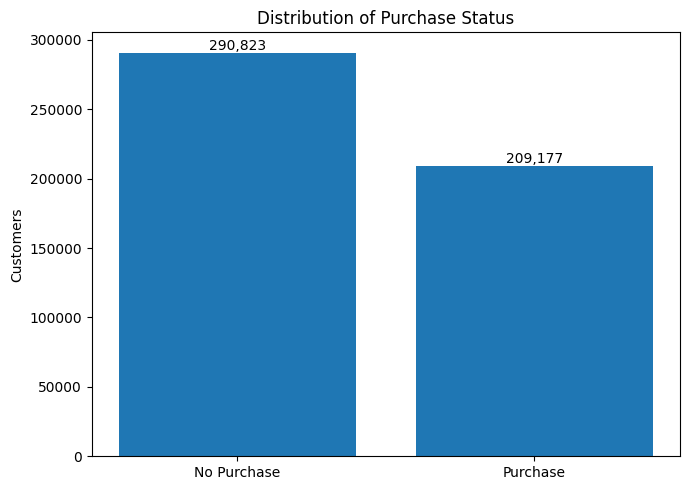

In [15]:
target_counts = (
    df_clean[TARGET]
    .value_counts()
    .sort_index()
)


plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    [
        "No Purchase",
        "Purchase"
    ],
    target_counts.values
)


for bar, count in zip(
    bars,
    target_counts.values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{count:,}",

        ha="center",
        va="bottom"
    )


plt.title(
    "Distribution of Purchase Status"
)

plt.ylabel(
    "Customers"
)

plt.tight_layout()
plt.show()

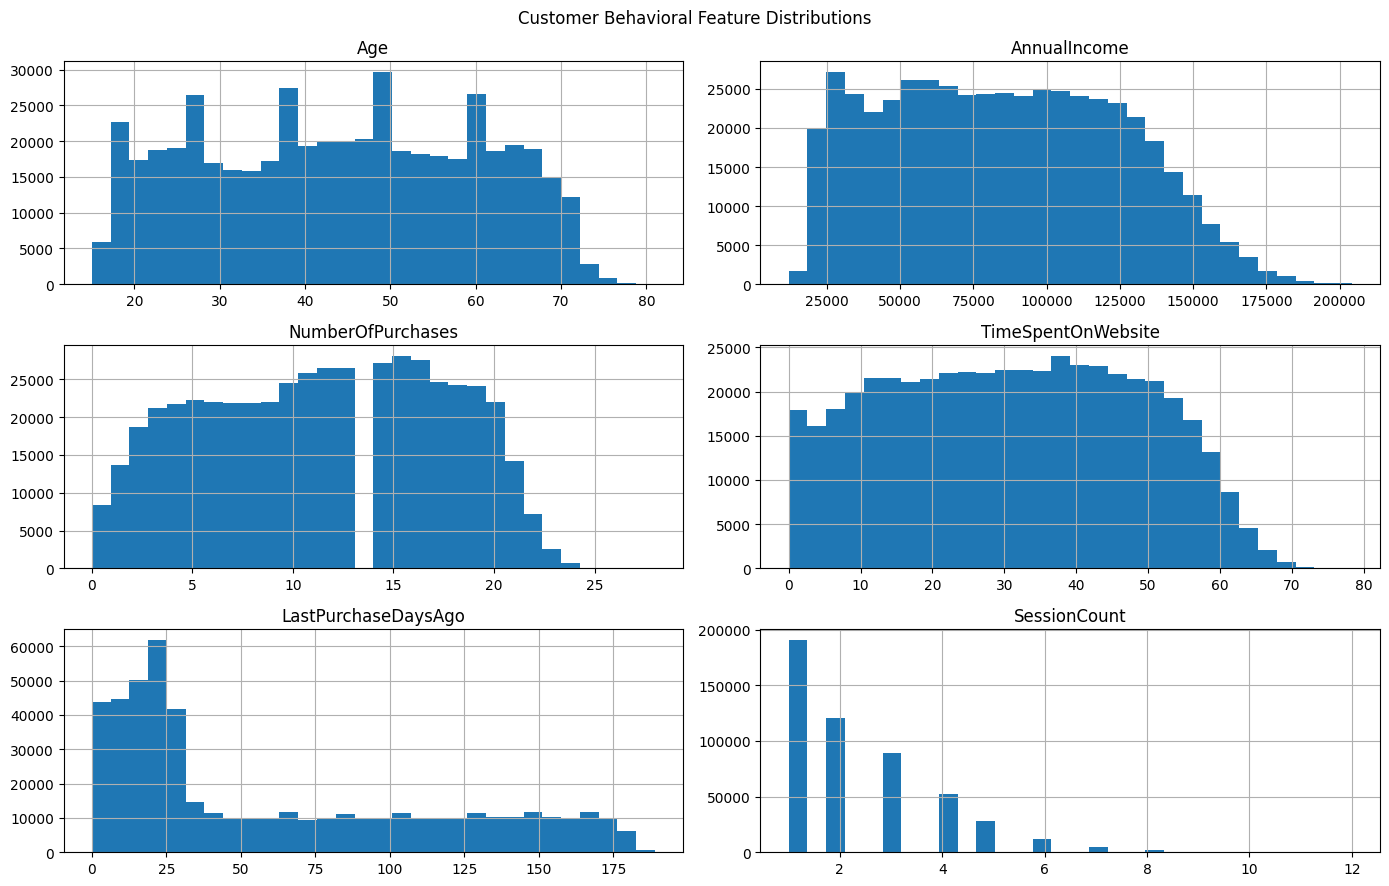

In [16]:
features_to_plot = [
    "Age",
    "AnnualIncome",
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "LastPurchaseDaysAgo",
    "SessionCount"
]


df_clean[
    features_to_plot
].hist(
    figsize=(14, 9),
    bins=30
)

plt.suptitle(
    "Customer Behavioral Feature Distributions"
)

plt.tight_layout()
plt.show()

,Customers,Purchase_Rate,Avg_Purchases
ProductCategory,,,
Furniture,95107,42.86,11.38
Fashion,111330,42.29,11.40
Electronics,95854,41.61,11.41
Kitchen,107712,41.27,11.41
Groceries,89997,41.11,11.39


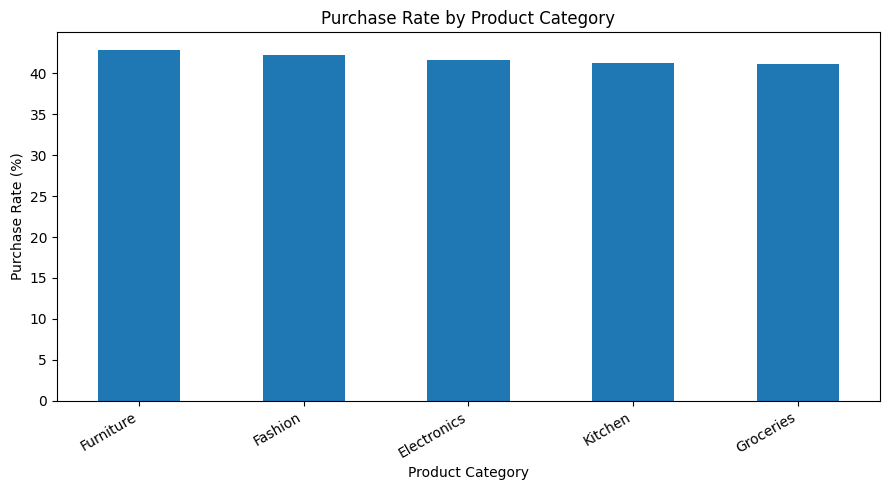

In [17]:
category_summary = (
    df_clean
    .groupby(
        "ProductCategory"
    )
    .agg(
        Customers=(
            TARGET,
            "size"
        ),

        Purchase_Rate=(
            TARGET,
            "mean"
        ),

        Avg_Purchases=(
            "NumberOfPurchases",
            "mean"
        )
    )
)


category_summary[
    "Purchase_Rate"
] *= 100


display(
    category_summary
    .sort_values(
        "Purchase_Rate",
        ascending=False
    )
    .round(2)
)


plt.figure(
    figsize=(9, 5)
)


purchase_by_category = (
    df_clean
    .groupby(
        "ProductCategory"
    )[TARGET]
    .mean()
    * 100
)


purchase_by_category = (
    purchase_by_category
    .sort_values(
        ascending=False
    )
)


purchase_by_category.plot(
    kind="bar"
)


plt.title(
    "Purchase Rate by Product Category"
)

plt.ylabel(
    "Purchase Rate (%)"
)

plt.xlabel(
    "Product Category"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [18]:
behavior_columns = [
    "CustomerSegment",
    "PreferredDevice",
    "ReferralSource",
    "Region",
    "Gender"
]


for col in behavior_columns:

    rates = (
        df_clean
        .groupby(col)[TARGET]
        .mean()
        .sort_values(
            ascending=False
        )
        * 100
    )


    print(
        f"\n===== PURCHASE RATE BY {col} ====="
    )

    display(
        rates
        .to_frame(
            "Purchase_Rate_Percent"
        )
        .round(2)
    )


===== PURCHASE RATE BY CustomerSegment =====


,Purchase_Rate_Percent
CustomerSegment,
Regular,44.26
Premium,43.23
VIP,37.76



===== PURCHASE RATE BY PreferredDevice =====


,Purchase_Rate_Percent
PreferredDevice,
Tablet,42.50
Desktop,41.78
Mobile,41.69



===== PURCHASE RATE BY ReferralSource =====


,Purchase_Rate_Percent
ReferralSource,
Referral,42.48
Organic,41.87
Email,41.86
Social,41.71
Paid Ads,41.60



===== PURCHASE RATE BY Region =====


,Purchase_Rate_Percent
Region,
North,42.17
West,42.04
South,41.70
East,41.44



===== PURCHASE RATE BY Gender =====


,Purchase_Rate_Percent
Gender,
Male,42.28
Female,41.38


In [19]:
loyalty_summary = (
    df_clean
    .groupby(
        "LoyaltyProgram"
    )
    .agg(
        Customers=(
            TARGET,
            "size"
        ),

        Purchase_Rate=(
            TARGET,
            "mean"
        ),

        Avg_Purchases=(
            "NumberOfPurchases",
            "mean"
        ),

        Avg_Sessions=(
            "SessionCount",
            "mean"
        )
    )
)


loyalty_summary[
    "Purchase_Rate"
] *= 100


display(
    loyalty_summary.round(2)
)

,Customers,Purchase_Rate,Avg_Purchases,Avg_Sessions
LoyaltyProgram,,,,
0.0,249445,37.61,10.53,2.35
1.0,250555,46.04,12.26,2.35


In [20]:
selected_behavior = [
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "LastPurchaseDaysAgo",
    "SessionCount",
    "CustomerSatisfaction"
]


behavior_target_summary = (
    df_clean
    .groupby(
        TARGET
    )[
        selected_behavior
    ]
    .mean()
)


display(
    behavior_target_summary
    .round(2)
)

,NumberOfPurchases,TimeSpentOnWebsite,LastPurchaseDaysAgo,SessionCount,CustomerSatisfaction
PurchaseStatus,,,,,
0,11.06,30.22,92.83,2.35,3.13
1,11.87,32.40,15.53,2.35,3.34


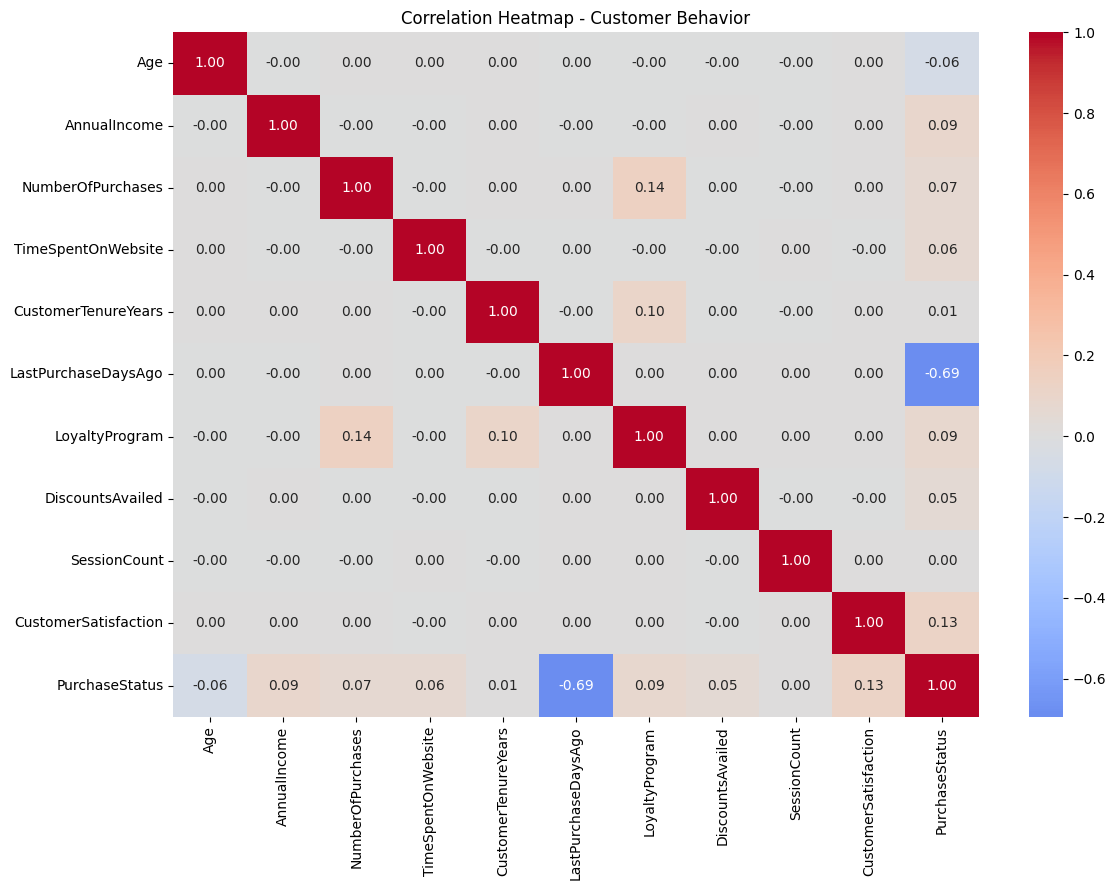

,Correlation_with_PurchaseStatus
CustomerSatisfaction,0.125
AnnualIncome,0.088
LoyaltyProgram,0.085
NumberOfPurchases,0.066
TimeSpentOnWebsite,0.062
DiscountsAvailed,0.052
CustomerTenureYears,0.006
SessionCount,0.001
Age,-0.064
LastPurchaseDaysAgo,-0.694


In [21]:
numeric_for_corr = (
    df_clean
    .select_dtypes(
        include="number"
    )
)


corr = (
    numeric_for_corr
    .corr()
)


plt.figure(
    figsize=(12, 9)
)


sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)


plt.title(
    "Correlation Heatmap - Customer Behavior"
)

plt.tight_layout()
plt.show()


target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(
        ascending=False
    )
)


display(
    target_corr
    .to_frame(
        "Correlation_with_PurchaseStatus"
    )
    .round(3)
)

## 9. Chia tập train, validation và test

Dữ liệu được chia độc lập theo tỷ lệ 70% train, 15% validation và 15% test, đồng thời giữ tỷ lệ nhãn bằng stratify. Tập test không được dùng để fit tiền xử lý hoặc chọn mô hình.

In [22]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )
)


X_val, X_test, y_val, y_test = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temp
    )
)


split_table = pd.DataFrame({
    "Set": [
        "Train",
        "Validation",
        "Test"
    ],

    "Rows": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],

    "Percent": [
        len(X_train)
        / len(X)
        * 100,

        len(X_val)
        / len(X)
        * 100,

        len(X_test)
        / len(X)
        * 100
    ],

    "Purchase_Rate_Percent": [
        y_train.mean()
        * 100,

        y_val.mean()
        * 100,

        y_test.mean()
        * 100
    ]
})


display(
    split_table.round(2)
)

,Set,Rows,Percent,Purchase_Rate_Percent
0,Train,350000,70.0,41.84
1,Validation,75000,15.0,41.84
2,Test,75000,15.0,41.83


## 10. Pipeline tiền xử lý

Biến số được impute và chuẩn hóa, biến nhị phân được impute, còn biến phân loại được one-hot encoding. Mọi phép biến đổi cần fit đều nằm trong pipeline để tránh leakage.

In [23]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])


binary_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),

        (
            "binary",
            binary_pipeline,
            binary_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],

    sparse_threshold=1.0
)


print(
    preprocessor
)

ColumnTransformer(sparse_threshold=1.0,
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'NumberOfPurchases',
                                  'TimeSpentOnWebsite', 'CustomerTenureYears',
                                  'LastPurchaseDaysAgo', 'DiscountsAvailed',
                                  'SessionCount', 'CustomerSatisfaction']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['LoyaltyProgram']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                              

## 11. Mô hình cơ sở

Dummy Classifier dự đoán lớp chiếm đa số được dùng làm mốc tối thiểu và cho thấy Accuracy không đủ để đánh giá toàn diện khả năng dự đoán mua hàng.

In [24]:
baseline = Pipeline([
    (
        "preprocessor",
        clone(
            preprocessor
        )
    ),

    (
        "model",
        DummyClassifier(
            strategy="most_frequent"
        )
    )
])


baseline.fit(
    X_train,
    y_train
)


baseline_pred = (
    baseline
    .predict(
        X_val
    )
)


baseline_result = pd.DataFrame([{
    "Model":
        "Dummy Baseline",

    "Accuracy":
        accuracy_score(
            y_val,
            baseline_pred
        ),

    "Precision":
        precision_score(
            y_val,
            baseline_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_val,
            baseline_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_val,
            baseline_pred,
            zero_division=0
        )
}])


display(
    baseline_result.round(4)
)

,Model,Accuracy,Precision,Recall,F1
0,Dummy Baseline,0.5816,0.0,0.0,0.0


## 12. Xây dựng mô hình

Sáu bộ phân loại cổ điển được huấn luyện bằng cùng biểu diễn dữ liệu bảng và cùng cách chia dữ liệu. Do dataset không có bình luận nên cả sáu mô hình sử dụng đặc trưng khách hàng dạng bảng.

In [25]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),


    "Decision Tree":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),


    "Random Forest":
        RandomForestClassifier(
            n_estimators=150,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),


    "Linear SVM":
        LinearSVC(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ),


    "SGD Linear Classifier":
        SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ),


    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=150,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}


print(
    "Number of models:",
    len(models)
)

Number of models: 6


In [26]:
def get_score_values(
    model,
    X_data
):

    if hasattr(
        model,
        "predict_proba"
    ):

        return (
            model
            .predict_proba(
                X_data
            )[:, 1]
        )


    if hasattr(
        model,
        "decision_function"
    ):

        return (
            model
            .decision_function(
                X_data
            )
        )


    return None

In [27]:
results = []

trained_models = {}


for name, estimator in models.items():

    print(
        f"Training {name}..."
    )


    pipeline = Pipeline([
        (
            "preprocessor",
            clone(
                preprocessor
            )
        ),

        (
            "model",
            clone(
                estimator
            )
        )
    ])


    start = time.time()


    pipeline.fit(
        X_train,
        y_train
    )


    training_time = (
        time.time()
        - start
    )


    pred = (
        pipeline
        .predict(
            X_val
        )
    )


    score_values = (
        get_score_values(
            pipeline,
            X_val
        )
    )


    results.append({

        "Model":
            name,

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Precision":
            precision_score(
                y_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                score_values
            ),

        "Training_Time_s":
            training_time
    })


    trained_models[
        name
    ] = pipeline


    print(
        f"Done: {training_time:.2f}s\n"
    )


results_df = pd.DataFrame(
    results
)


results_df = (
    results_df
    .sort_values(
        by=[
            "F1",
            "ROC_AUC",
            "Recall"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    results_df.round(4)
)

Training Logistic Regression...
Done: 2.06s

Training Decision Tree...
Done: 58.41s

Training Random Forest...
Done: 226.52s

Training Linear SVM...
Done: 1.89s

Training SGD Linear Classifier...
Done: 1.77s

Training Extra Trees...
Done: 638.28s



,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s
0,Random Forest,0.9170,0.8754,0.9347,0.9041,0.9764,226.5231
1,Logistic Regression,0.9142,0.8633,0.9444,0.9020,0.9774,2.0648
2,SGD Linear Classifier,0.9142,0.8632,0.9445,0.9020,0.9772,1.7683
3,Linear SVM,0.9134,0.8596,0.9479,0.9016,0.9774,1.8861
4,Extra Trees,0.9117,0.8687,0.9294,0.8980,0.9737,638.2808
5,Decision Tree,0.8797,0.8627,0.8475,0.8550,0.8752,58.4091


## 13. Biểu diễn số cuối cùng

Phần này minh họa một hồ sơ khách hàng thô được chuyển thành vector số sau impute, chuẩn hóa và one-hot encoding, cùng kích thước ma trận cuối.

In [28]:
example_pipeline = (
    trained_models[
        "Logistic Regression"
    ]
)


fitted_preprocessor = (
    example_pipeline
    .named_steps[
        "preprocessor"
    ]
)


raw_sample = (
    X_train.iloc[[0]]
)


transformed_sample = (
    fitted_preprocessor
    .transform(
        raw_sample
    )
)


X_train_transformed = (
    fitted_preprocessor
    .transform(
        X_train
    )
)


feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


print(
    "Raw customer shape:",
    raw_sample.shape
)

print(
    "Transformed customer shape:",
    transformed_sample.shape
)

print(
    "Raw training matrix shape:",
    X_train.shape
)

print(
    "Final model-input shape:",
    X_train_transformed.shape
)

print(
    "Final feature dimension:",
    len(feature_names)
)

print(
    "\nFirst transformed feature names:"
)

print(
    feature_names[:40]
)

Raw customer shape: (1, 16)
Transformed customer shape: (1, 32)
Raw training matrix shape: (350000, 16)
Final model-input shape: (350000, 32)
Final feature dimension: 32

First transformed feature names:
['num__Age' 'num__AnnualIncome' 'num__NumberOfPurchases'
 'num__TimeSpentOnWebsite' 'num__CustomerTenureYears'
 'num__LastPurchaseDaysAgo' 'num__DiscountsAvailed' 'num__SessionCount'
 'num__CustomerSatisfaction' 'binary__LoyaltyProgram' 'cat__Gender_Female'
 'cat__Gender_Male' 'cat__ProductCategory_Electronics'
 'cat__ProductCategory_Fashion' 'cat__ProductCategory_Furniture'
 'cat__ProductCategory_Groceries' 'cat__ProductCategory_Kitchen'
 'cat__PreferredDevice_Desktop' 'cat__PreferredDevice_Mobile'
 'cat__PreferredDevice_Tablet' 'cat__Region_East' 'cat__Region_North'
 'cat__Region_South' 'cat__Region_West' 'cat__ReferralSource_Email'
 'cat__ReferralSource_Organic' 'cat__ReferralSource_Paid Ads'
 'cat__ReferralSource_Referral' 'cat__ReferralSource_Social'
 'cat__CustomerSegment_Premium

## 14. So sánh trên tập validation

Các mô hình được so sánh bằng Accuracy, Precision, Recall, F1-score, ROC-AUC và thời gian huấn luyện. F1 và ROC-AUC phản ánh hiệu quả giữa các lớp tốt hơn Accuracy đơn lẻ.

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s
0,Random Forest,0.9170,0.8754,0.9347,0.9041,0.9764,226.5231
1,Logistic Regression,0.9142,0.8633,0.9444,0.9020,0.9774,2.0648
2,SGD Linear Classifier,0.9142,0.8632,0.9445,0.9020,0.9772,1.7683
3,Linear SVM,0.9134,0.8596,0.9479,0.9016,0.9774,1.8861
4,Extra Trees,0.9117,0.8687,0.9294,0.8980,0.9737,638.2808
5,Decision Tree,0.8797,0.8627,0.8475,0.8550,0.8752,58.4091


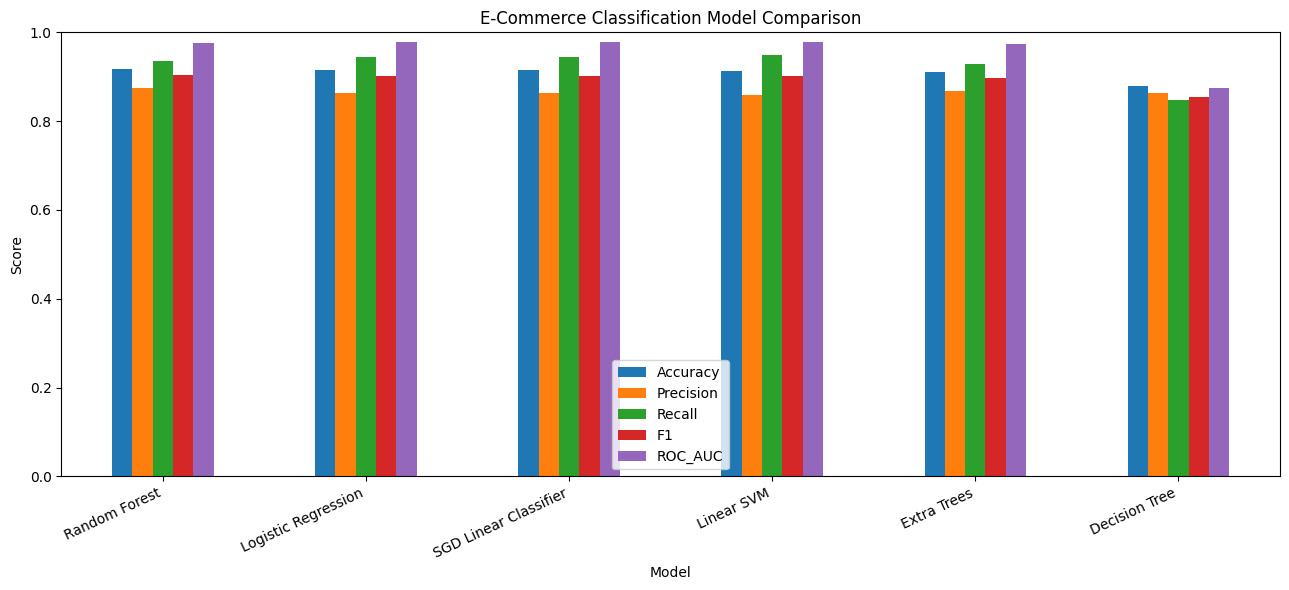

In [29]:
display(
    results_df.round(4)
)


comparison = (
    results_df
    .set_index(
        "Model"
    )[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
)


comparison.plot(
    kind="bar",
    figsize=(13, 6)
)


plt.title(
    "E-Commerce Classification Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

## 15. Chọn mô hình cuối cùng

Logistic Regression được chọn để triển khai vì F1 gần bằng Random Forest, ROC-AUC cao hơn một chút, đồng thời nhanh hơn, nhẹ hơn và dễ giải thích hơn đáng kể.

Selected final model: Logistic Regression


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s
0,Random Forest,0.9170,0.8754,0.9347,0.9041,0.9764,226.5231
1,Logistic Regression,0.9142,0.8633,0.9444,0.9020,0.9774,2.0648



===== SELECTION REASON =====
Logistic Regression was selected as the final deployment model.
Its F1-score is very close to Random Forest, while its ROC-AUC is slightly higher.
It also requires much less training time and produces a much smaller persisted model.

===== VALIDATION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92     43623
    Purchase       0.86      0.94      0.90     31377

    accuracy                           0.91     75000
   macro avg       0.91      0.92      0.91     75000
weighted avg       0.92      0.91      0.91     75000



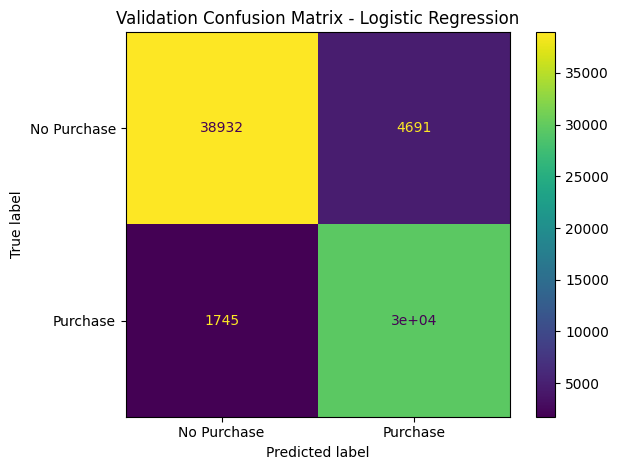

In [37]:
# =========================
# FINAL MODEL SELECTION
# =========================

# Random Forest có F1 cao nhất một chút,
# nhưng Logistic Regression nhẹ hơn rất nhiều,
# train nhanh hơn và ROC-AUC còn cao hơn.
# Vì mục tiêu cuối là deployment nên chọn Logistic Regression.

best_name = "Logistic Regression"

best_model = trained_models[
    best_name
]


print(
    "Selected final model:",
    best_name
)


# So sánh trực tiếp 2 model mạnh nhất
deployment_comparison = (
    results_df[
        results_df["Model"].isin([
            "Random Forest",
            "Logistic Regression"
        ])
    ]
    .copy()
)


display(
    deployment_comparison.round(4)
)


print(
    "\n===== SELECTION REASON ====="
)

print(
    "Logistic Regression was selected as the final deployment model."
)

print(
    "Its F1-score is very close to Random Forest, "
    "while its ROC-AUC is slightly higher."
)

print(
    "It also requires much less training time "
    "and produces a much smaller persisted model."
)


# Validation prediction của model cuối
val_pred = (
    best_model
    .predict(
        X_val
    )
)


print(
    "\n===== VALIDATION CLASSIFICATION REPORT ====="
)

print(
    classification_report(
        y_val,
        val_pred,
        target_names=[
            "No Purchase",
            "Purchase"
        ],
        zero_division=0
    )
)


# Validation confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred,
    display_labels=[
        "No Purchase",
        "Purchase"
    ]
)

plt.title(
    f"Validation Confusion Matrix - {best_name}"
)

plt.tight_layout()
plt.show()

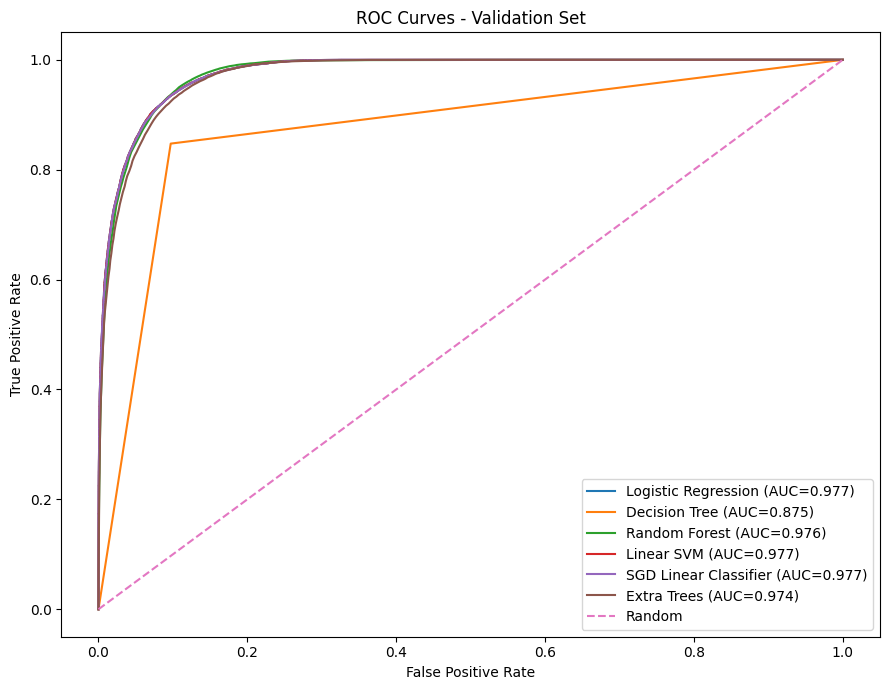

In [38]:
plt.figure(
    figsize=(9, 7)
)


for name, model in trained_models.items():

    scores = (
        get_score_values(
            model,
            X_val
        )
    )


    fpr, tpr, _ = (
        roc_curve(
            y_val,
            scores
        )
    )


    auc_value = (
        roc_auc_score(
            y_val,
            scores
        )
    )


    plt.plot(
        fpr,
        tpr,
        label=(
            f"{name} "
            f"(AUC={auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves - Validation Set"
)

plt.legend()

plt.tight_layout()
plt.show()

## 16. Huấn luyện lại và đánh giá trên tập test

Pipeline được chọn được huấn luyện lại bằng train cộng validation rồi đánh giá một lần trên tập test chưa từng được sử dụng.

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9143,0.864,0.9437,0.9021,0.9769


              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92     43624
    Purchase       0.86      0.94      0.90     31376

    accuracy                           0.91     75000
   macro avg       0.91      0.92      0.91     75000
weighted avg       0.92      0.91      0.91     75000



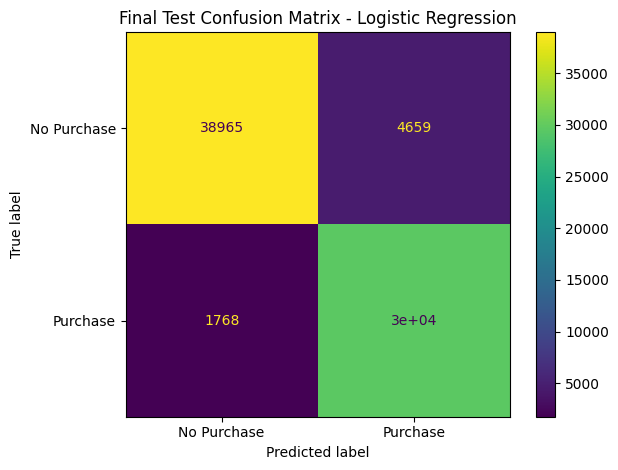

In [39]:
X_train_final = pd.concat(
    [
        X_train,
        X_val
    ],
    axis=0
)


y_train_final = pd.concat(
    [
        y_train,
        y_val
    ],
    axis=0
)


final_model = clone(
    best_model
)


final_model.fit(
    X_train_final,
    y_train_final
)


test_pred = (
    final_model
    .predict(
        X_test
    )
)


test_scores = (
    get_score_values(
        final_model,
        X_test
    )
)


test_results = pd.DataFrame([{

    "Model":
        best_name,

    "Accuracy":
        accuracy_score(
            y_test,
            test_pred
        ),

    "Precision":
        precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            test_scores
        )

}])


display(
    test_results.round(4)
)


print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Purchase",
            "Purchase"
        ],
        zero_division=0
    )
)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=[
        "No Purchase",
        "Purchase"
    ]
)


plt.title(
    f"Final Test Confusion Matrix - {best_name}"
)

plt.tight_layout()
plt.show()

## 17. Phân tích lỗi

False Negative là khách hàng thực sự mua nhưng bị dự đoán không mua; False Positive là khách hàng không mua nhưng vẫn bị nhắm mục tiêu không cần thiết.

In [40]:
tn, fp, fn, tp = (
    confusion_matrix(
        y_test,
        test_pred
    )
    .ravel()
)


error_analysis = pd.DataFrame({
    "Metric": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
        "False Positive Rate",
        "False Negative Rate"
    ],

    "Value": [
        tn,
        fp,
        fn,
        tp,

        fp / (
            fp + tn
        ),

        fn / (
            fn + tp
        )
    ]
})


display(
    error_analysis.round(4)
)

,Metric,Value
0,True Negative,38965.0000
1,False Positive,4659.0000
2,False Negative,1768.0000
3,True Positive,29608.0000
4,False Positive Rate,0.1068
5,False Negative Rate,0.0563


## 18. Mức độ quan trọng của đặc trưng

Giá trị tuyệt đối của hệ số Logistic Regression được dùng để chỉ ra các đặc trưng hành vi đã biến đổi có ảnh hưởng mạnh nhất đến ranh giới quyết định.

,Feature,Importance
0,num__LastPurchaseDaysAgo,9.432800
1,cat__CustomerSegment_VIP,1.327355
2,binary__LoyaltyProgram,1.298352
3,cat__Gender_Female,1.051490
4,num__CustomerSatisfaction,1.036950
5,cat__Gender_Male,0.914003
6,num__AnnualIncome,0.713425
7,cat__PreferredDevice_Mobile,0.692059
8,cat__PreferredDevice_Desktop,0.682578
9,cat__Region_East,0.606943


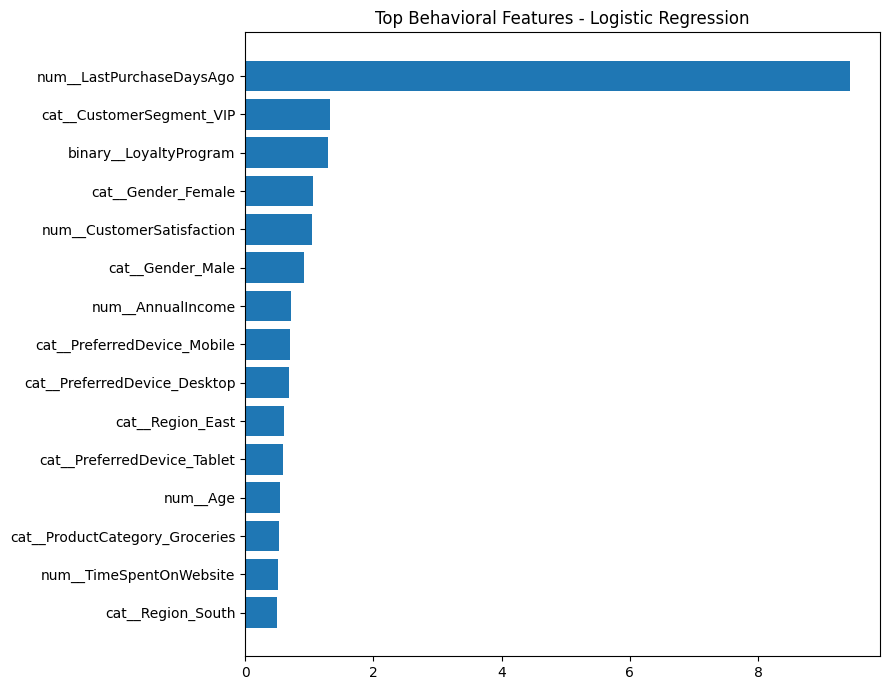

In [41]:
model_step = (
    final_model
    .named_steps[
        "model"
    ]
)


final_preprocessor = (
    final_model
    .named_steps[
        "preprocessor"
    ]
)


final_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)


importance_values = None


if hasattr(
    model_step,
    "feature_importances_"
):

    importance_values = (
        model_step
        .feature_importances_
    )


elif hasattr(
    model_step,
    "coef_"
):

    importance_values = (
        np.abs(
            model_step
            .coef_[0]
        )
    )


if importance_values is not None:

    importance_df = pd.DataFrame({
        "Feature":
            final_feature_names,

        "Importance":
            importance_values
    })


    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    display(
        importance_df.head(20)
    )


    top_features = (
        importance_df
        .head(15)
        .sort_values(
            "Importance"
        )
    )


    plt.figure(
        figsize=(9, 7)
    )


    plt.barh(
        top_features[
            "Feature"
        ],

        top_features[
            "Importance"
        ]
    )


    plt.title(
        f"Top Behavioral Features - {best_name}"
    )

    plt.tight_layout()
    plt.show()


else:

    print(
        "Selected model does not expose "
        "feature_importances_ or coef_."
    )

## 19. Lưu mô hình

Tiền xử lý và Logistic Regression đã fit được lưu chung để quá trình triển khai dùng đúng thứ tự đặc trưng, impute, chuẩn hóa và encoding khi huấn luyện.

In [42]:
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_PATH = (
    MODEL_DIR
    /
    "ecommerce_purchase_pipeline.joblib"
)


artifact = {

    "pipeline":
        final_model,

    "model_name":
        best_name,

    "raw_feature_names":
        X.columns.tolist(),

    "numerical_features":
        numerical_features,

    "binary_features":
        binary_features,

    "categorical_features":
        categorical_features,

    "target":
        TARGET,

    "random_state":
        RANDOM_STATE,

    "test_metrics":
        test_results
        .iloc[0]
        .to_dict()
}


joblib.dump(
    artifact,
    MODEL_PATH
)


print(
    "Saved model:",
    MODEL_PATH
)

Saved model: D:\Assignment2\models\ecommerce_purchase_pipeline.joblib


## 20. Dự đoán cho khách hàng mới

Artifact đã lưu được tải lại và áp dụng cho một hồ sơ khách hàng mới có đúng schema đặc trưng thô mà pipeline yêu cầu.

In [43]:
loaded_artifact = (
    joblib.load(
        MODEL_PATH
    )
)


loaded_model = (
    loaded_artifact[
        "pipeline"
    ]
)


new_customer = pd.DataFrame([{

    "Age": 32,

    "AnnualIncome": 65000,

    "NumberOfPurchases": 12,

    "TimeSpentOnWebsite": 8.5,

    "CustomerTenureYears": 3.2,

    "LastPurchaseDaysAgo": 14,

    "Gender": "Female",

    "ProductCategory": "Fashion",

    "PreferredDevice": "Mobile",

    "Region": "North",

    "ReferralSource": "Organic",

    "CustomerSegment": "Regular",

    "LoyaltyProgram": 1,

    "DiscountsAvailed": 3,

    "SessionCount": 8,

    "CustomerSatisfaction": 4

}])


new_customer = new_customer[
    loaded_artifact[
        "raw_feature_names"
    ]
]


print(
    "===== NEW CUSTOMER INPUT ====="
)


display(
    new_customer
)


prediction = int(
    loaded_model
    .predict(
        new_customer
    )[0]
)


print(
    "Loaded model:",
    loaded_artifact[
        "model_name"
    ]
)


print(
    "Predicted class:",
    prediction
)


print(
    "Prediction:",
    "Purchase"
    if prediction == 1
    else "No Purchase"
)


if hasattr(
    loaded_model,
    "predict_proba"
):

    probability_estimate = (
        loaded_model
        .predict_proba(
            new_customer
        )[0, 1]
    )


    print(
        "Model probability estimate:",
        round(
            probability_estimate,
            4
        )
    )


elif hasattr(
    loaded_model,
    "decision_function"
):

    decision_score = (
        loaded_model
        .decision_function(
            new_customer
        )[0]
    )


    print(
        "Model decision score:",
        round(
            float(
                decision_score
            ),
            4
        )
    )

===== NEW CUSTOMER INPUT =====


,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction
0,32,65000,12,8.5,3.2,14,Female,Fashion,Mobile,North,Organic,Regular,1,3,8,4


Loaded model: Logistic Regression
Predicted class: 1
Prediction: Purchase
Model probability estimate: 0.9915
